## Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

FIG_DIR = '../reports/figures'


## Load Raw Data

In [4]:
df = pd.read_csv('../data/raw/Walmart_Sales.csv')
print('Shape:', df.shape)
df.head()


Shape: (6435, 8)


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,"1,643,690.90",0,42.31,2.57,211.10,8.11
1,1,12-02-2010,"1,641,957.44",1,38.51,2.55,211.24,8.11
2,1,19-02-2010,"1,611,968.17",0,39.93,2.51,211.29,8.11
3,1,26-02-2010,"1,409,727.59",0,46.63,2.56,211.32,8.11
4,1,05-03-2010,"1,554,806.68",0,46.50,2.62,211.35,8.11


## Data Quality Assessment


In [5]:
print('--- dtypes ---')
print(df.dtypes)
print()
print('--- missing values ---')
print(df.isnull().sum())
print()
print('--- duplicate rows ---', df.duplicated().sum())
print()
print('--- unique stores ---', df['Store'].nunique())
print()
print('--- Holiday_Flag distribution ---')
print(df['Holiday_Flag'].value_counts())
print()
df.describe()


--- dtypes ---
Store             int64
Date             object
Weekly_Sales    float64
Holiday_Flag      int64
Temperature     float64
Fuel_Price      float64
CPI             float64
Unemployment    float64
dtype: object

--- missing values ---
Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

--- duplicate rows --- 0

--- unique stores --- 45

--- Holiday_Flag distribution ---
Holiday_Flag
0    5985
1     450
Name: count, dtype: int64



,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,"6,435.00","6,435.00","6,435.00","6,435.00","6,435.00","6,435.00","6,435.00"
mean,23.00,"1,046,964.88",0.07,60.66,3.36,171.58,8.00
std,12.99,"564,366.62",0.26,18.44,0.46,39.36,1.88
min,1.00,"209,986.25",0.00,-2.06,2.47,126.06,3.88
25%,12.00,"553,350.10",0.00,47.46,2.93,131.74,6.89
50%,23.00,"960,746.04",0.00,62.67,3.44,182.62,7.87
75%,34.00,"1,420,158.66",0.00,74.94,3.73,212.74,8.62
max,45.00,"3,818,686.45",1.00,100.14,4.47,227.23,14.31


**Findings:**
- No missing values and no duplicate rows — the dataset is clean at the row level.
- `Date` is stored as text (`DD-MM-DD-YYYY` style) and must be converted to a real datetime type before any time-based analysis.
- 45 stores, each with exactly 143 weekly observations — a perfectly balanced panel, which is unusual for
  real-world retail data and worth calling out explicitly (no store has gaps or extra records).
- Only 450 of 6,435 rows (7%) are holiday weeks — expected, since only 10 calendar weeks across the
  3 years are flagged (Super Bowl, Labor Day, Thanksgiving, Christmas).

## Data Cleaning

In [6]:
df_clean = df.copy()

# Convert Date to proper datetime
df_clean['Date'] = pd.to_datetime(df_clean['Date'], format='%d-%m-%Y')

# Sort chronologically within each store (industry standard for any time-series work)
df_clean = df_clean.sort_values(['Store', 'Date']).reset_index(drop=True)

# Defensive checks: negative or zero sales, impossible values
print('Rows with Weekly_Sales <= 0:', (df_clean['Weekly_Sales'] <= 0).sum())
print('Rows with Unemployment <= 0:', (df_clean['Unemployment'] <= 0).sum())
print('Date range:', df_clean['Date'].min().date(), 'to', df_clean['Date'].max().date())

df_clean.head()


Rows with Weekly_Sales <= 0: 0
Rows with Unemployment <= 0: 0
Date range: 2010-02-05 to 2012-10-26


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,"1,643,690.90",0,42.31,2.57,211.10,8.11
1,1,2010-02-12,"1,641,957.44",1,38.51,2.55,211.24,8.11
2,1,2010-02-19,"1,611,968.17",0,39.93,2.51,211.29,8.11
3,1,2010-02-26,"1,409,727.59",0,46.63,2.56,211.32,8.11
4,1,2010-03-05,"1,554,806.68",0,46.50,2.62,211.35,8.11


## Feature Engineering

Weekly retail sales are inherently seasonal, so the model needs explicit calendar features rather
than relying on the raw date. We also derive a holiday-week boolean for readability and a
revenue-rank feature for store benchmarking

In [7]:
df_clean['Year'] = df_clean['Date'].dt.year
df_clean['Month'] = df_clean['Date'].dt.month
df_clean['Month_Name'] = df_clean['Date'].dt.month_name()
df_clean['Quarter'] = df_clean['Date'].dt.quarter
df_clean['Week_Of_Year'] = df_clean['Date'].dt.isocalendar().week.astype(int)
df_clean['Is_Holiday_Week'] = df_clean['Holiday_Flag'].map({1: 'Holiday', 0: 'Non-Holiday'})

# Store performance tier (quartile rank of each store's average weekly sales) -- useful Power BI slicer
store_avg = df_clean.groupby('Store')['Weekly_Sales'].mean()
store_tier = pd.qcut(store_avg, 4, labels=['D - Bottom 25%', 'C', 'B', 'A - Top 25%'])
df_clean['Store_Tier'] = df_clean['Store'].map(store_tier)

# Week-over-week change per store (useful for trend visuals)
df_clean['WoW_Sales_Change_Pct'] = (
    df_clean.groupby('Store')['Weekly_Sales'].pct_change() * 100
)

df_clean.head()


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Month_Name,Quarter,Week_Of_Year,Is_Holiday_Week,Store_Tier,WoW_Sales_Change_Pct
0,1,2010-02-05,"1,643,690.90",0,42.31,2.57,211.10,8.11,2010,2,February,1,5,Non-Holiday,A - Top 25%,NaN
1,1,2010-02-12,"1,641,957.44",1,38.51,2.55,211.24,8.11,2010,2,February,1,6,Holiday,A - Top 25%,-0.11
2,1,2010-02-19,"1,611,968.17",0,39.93,2.51,211.29,8.11,2010,2,February,1,7,Non-Holiday,A - Top 25%,-1.83
3,1,2010-02-26,"1,409,727.59",0,46.63,2.56,211.32,8.11,2010,2,February,1,8,Non-Holiday,A - Top 25%,-12.55
4,1,2010-03-05,"1,554,806.68",0,46.50,2.62,211.35,8.11,2010,3,March,1,9,Non-Holiday,A - Top 25%,10.29


## Univariate Analysis

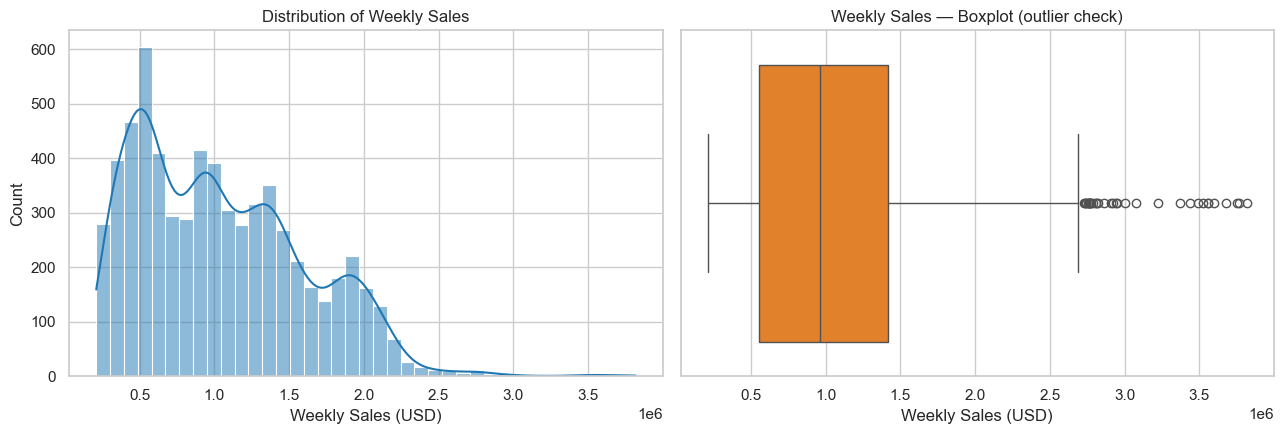

count       6,435.00
mean    1,046,964.88
std       564,366.62
min       209,986.25
25%       553,350.10
50%       960,746.04
75%     1,420,158.66
max     3,818,686.45
Name: Weekly_Sales, dtype: float64


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(df_clean['Weekly_Sales'], kde=True, ax=axes[0], color='#1f77b4')
axes[0].set_title('Distribution of Weekly Sales')
axes[0].set_xlabel('Weekly Sales (USD)')

sns.boxplot(x=df_clean['Weekly_Sales'], ax=axes[1], color='#ff7f0e')
axes[1].set_title('Weekly Sales — Boxplot (outlier check)')
axes[1].set_xlabel('Weekly Sales (USD)')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/01_weekly_sales_distribution.png', bbox_inches='tight')
plt.show()

print(df_clean['Weekly_Sales'].describe())


**Finding:** the distribution is right-skewed with a cluster of high-value outliers — these turn
out to be concentrated in late-December weeks, not random noise.

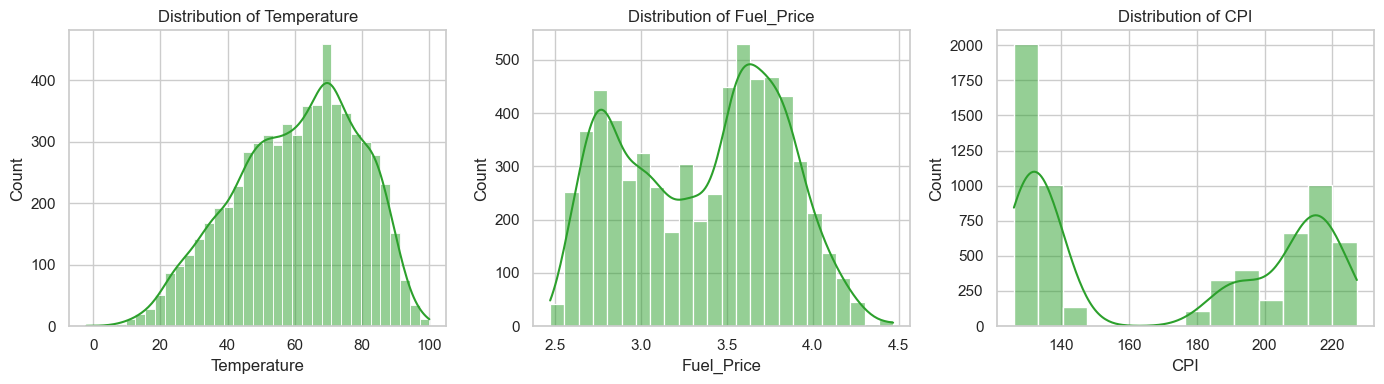

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['Temperature', 'Fuel_Price', 'CPI']):
    sns.histplot(df_clean[col], kde=True, ax=ax, color='#2ca02c')
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/02_economic_indicators_distribution.png', bbox_inches='tight')
plt.show()


## Time Series & Seasonality Analysis

Aggregate across all 45 stores to see the overall sales trend and look for recurring seasonal
patterns (month-of-year effects).

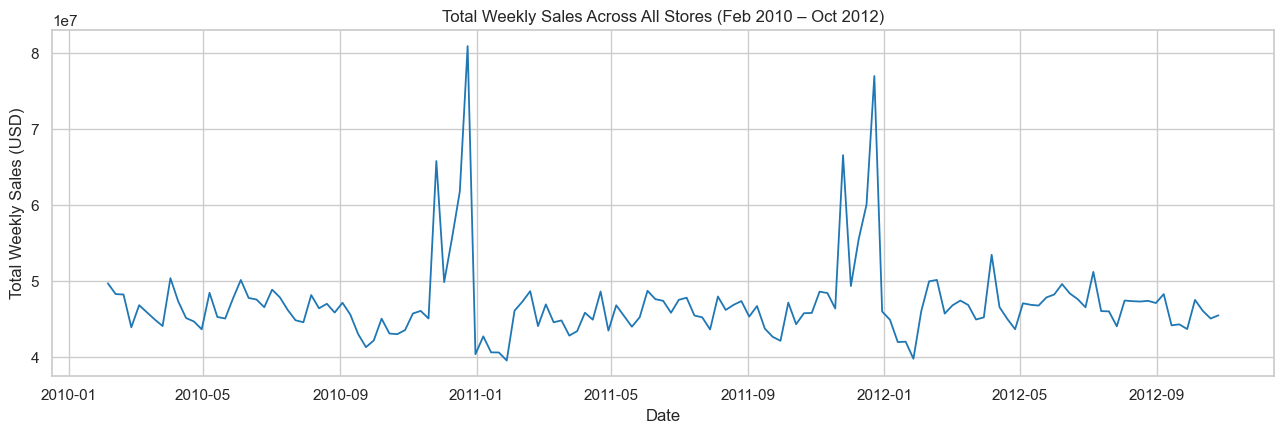

In [10]:
weekly_total = df_clean.groupby('Date')['Weekly_Sales'].sum().reset_index()

plt.figure(figsize=(13, 4.5))
plt.plot(weekly_total['Date'], weekly_total['Weekly_Sales'], color='#1f77b4', linewidth=1.3)
plt.title('Total Weekly Sales Across All Stores (Feb 2010 – Oct 2012)')
plt.xlabel('Date')
plt.ylabel('Total Weekly Sales (USD)')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/03_total_weekly_sales_trend.png', bbox_inches='tight')
plt.show()


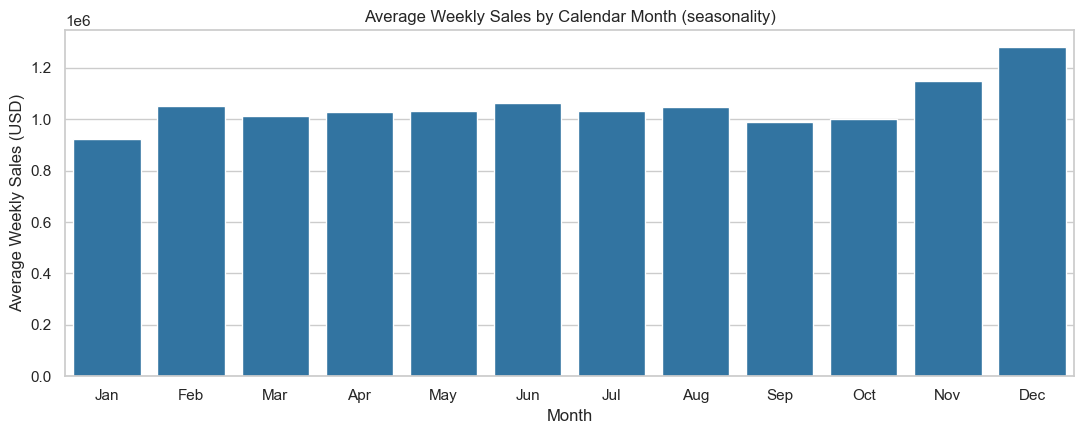

Highest avg sales month: Dec (1,281,864)
Lowest avg sales month: Jan (923,885)
Dec vs Jan uplift: 38.7%


In [11]:
monthly_avg = df_clean.groupby('Month')['Weekly_Sales'].mean().reindex(range(1, 13))
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(11, 4.5))
sns.barplot(x=month_labels, y=monthly_avg.values, color='#1f77b4')
plt.title('Average Weekly Sales by Calendar Month (seasonality)')
plt.ylabel('Average Weekly Sales (USD)')
plt.xlabel('Month')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/04_monthly_seasonality.png', bbox_inches='tight')
plt.show()

print('Highest avg sales month:', month_labels[monthly_avg.idxmax()-1], f'({monthly_avg.max():,.0f})')
print('Lowest avg sales month:', month_labels[monthly_avg.idxmin()-1], f'({monthly_avg.min():,.0f})')
print(f'Dec vs Jan uplift: {(monthly_avg[12]/monthly_avg[1]-1)*100:.1f}%')


**Finding:** December has the highest average weekly sales of any month and January the lowest —
a ~38% gap between the two — confirming strong holiday-season seasonality that should drive
inventory and staffing planning.

## Store-Level Performance Analysis

Not all 45 stores contribute equally. This section quantifies *how* concentrated revenue is across
the store network — a classic Pareto-style retail question.

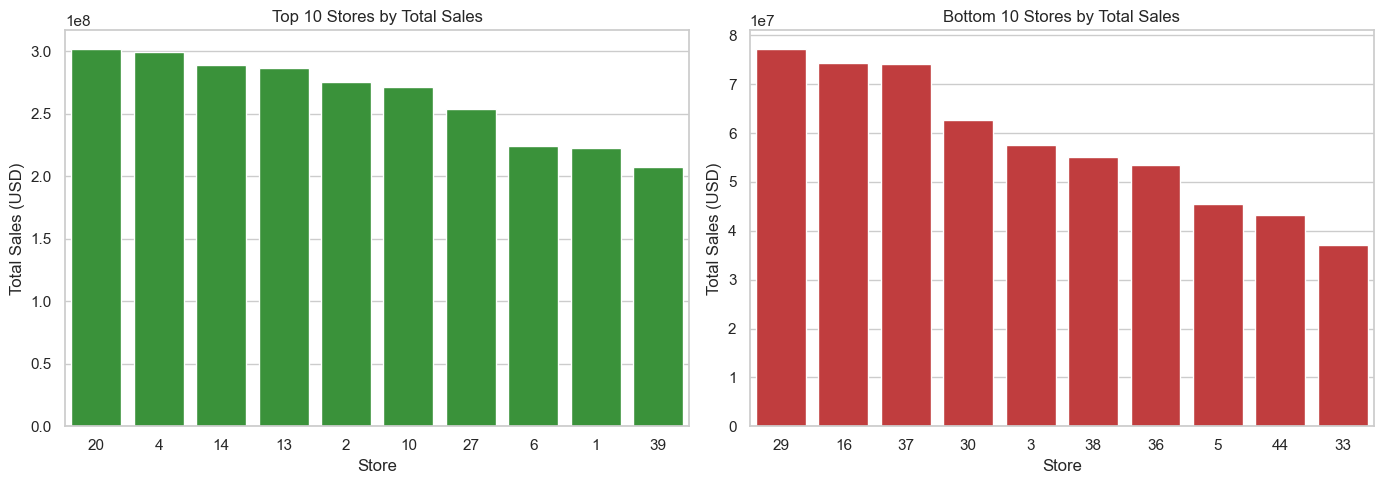

Top store (20) share of total network sales: 4.47%
Top 5 stores combined share: 21.55%
Top store avg weekly sales is 8.1x the bottom store's


In [12]:
store_perf = (
    df_clean.groupby('Store')['Weekly_Sales']
    .agg(Total_Sales='sum', Avg_Weekly_Sales='mean', Std_Weekly_Sales='std')
    .sort_values('Total_Sales', ascending=False)
)

total_sales = df_clean['Weekly_Sales'].sum()
store_perf['Pct_Of_Total'] = store_perf['Total_Sales'] / total_sales * 100
store_perf['Cumulative_Pct'] = store_perf['Pct_Of_Total'].cumsum()

top10 = store_perf.head(10)
bottom10 = store_perf.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=top10.index.astype(str), y=top10['Total_Sales'], ax=axes[0], color='#2ca02c')
axes[0].set_title('Top 10 Stores by Total Sales')
axes[0].set_xlabel('Store')
axes[0].set_ylabel('Total Sales (USD)')

sns.barplot(x=bottom10.index.astype(str), y=bottom10['Total_Sales'], ax=axes[1], color='#d62728')
axes[1].set_title('Bottom 10 Stores by Total Sales')
axes[1].set_xlabel('Store')
axes[1].set_ylabel('Total Sales (USD)')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/05_top_bottom_stores.png', bbox_inches='tight')
plt.show()

print(f"Top store ({top10.index[0]}) share of total network sales: {top10['Pct_Of_Total'].iloc[0]:.2f}%")
print(f"Top 5 stores combined share: {store_perf.head(5)['Pct_Of_Total'].sum():.2f}%")
print(f"Top store avg weekly sales is {top10['Avg_Weekly_Sales'].iloc[0]/bottom10['Avg_Weekly_Sales'].iloc[-1]:.1f}x the bottom store's")


**Finding:** the top store alone generates roughly 4.5% of network-wide sales, and the top 5
stores combine for over 21% — meaningful concentration, given there are 45 stores. The strongest
store averages roughly 8x the weekly sales of the weakest store.

## A/B Testing & Hypothesis Testing — Holiday vs Non-Holiday Sales


**Hypotheses:**
- **H0 (null):** mean weekly sales in holiday weeks = mean weekly sales in non-holiday weeks
- **H1 (alternative):** mean weekly sales in holiday weeks ≠ mean weekly sales in non-holiday weeks
- **Test:** Welch's two-sample t-test (unequal variances, unequal group sizes — 450 holiday weeks vs
  5,985 non-holiday weeks, so we can't assume equal variance)
- **Significance level:** α = 0.05

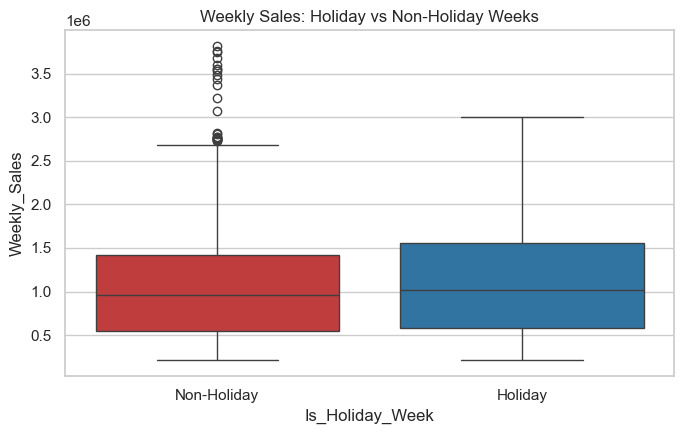

Holiday week avg sales:         1,122,888
Non-holiday week avg sales:     1,041,256
Lift:                               7.84%
t-statistic = 2.680,  p-value = 0.00760


In [13]:
holiday = df_clean.loc[df_clean['Holiday_Flag'] == 1, 'Weekly_Sales']
non_holiday = df_clean.loc[df_clean['Holiday_Flag'] == 0, 'Weekly_Sales']

t_stat, p_value = stats.ttest_ind(holiday, non_holiday, equal_var=False)
pct_lift = (holiday.mean() - non_holiday.mean()) / non_holiday.mean() * 100

plt.figure(figsize=(7, 4.5))
sns.boxplot(x=df_clean['Is_Holiday_Week'], y=df_clean['Weekly_Sales'], palette=['#d62728', '#1f77b4'])
plt.title('Weekly Sales: Holiday vs Non-Holiday Weeks')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/06_holiday_impact.png', bbox_inches='tight')
plt.show()

print(f'Holiday week avg sales:     {holiday.mean():>13,.0f}')
print(f'Non-holiday week avg sales: {non_holiday.mean():>13,.0f}')
print(f'Lift:                       {pct_lift:>12.2f}%')
print(f't-statistic = {t_stat:.3f},  p-value = {p_value:.5f}')


A p-value alone doesn't tell you whether the difference is big enough to matter — with a large
enough sample, even a tiny, useless difference can hit p < 0.05. The fix is to always report
**effect size** and a **confidence interval** alongside the p-value, and to check the test had enough
statistical **power** to detect that effect in the first place.

In [14]:
from statsmodels.stats.weightstats import CompareMeans, DescrStatsW
from statsmodels.stats.power import TTestIndPower

def cohens_d(a, b):
    na, nb = len(a), len(b)
    pooled_std = np.sqrt(((na - 1) * a.std(ddof=1) ** 2 + (nb - 1) * b.std(ddof=1) ** 2) / (na + nb - 2))
    return (a.mean() - b.mean()) / pooled_std

d = cohens_d(holiday, non_holiday)

cm = CompareMeans(DescrStatsW(holiday), DescrStatsW(non_holiday))
ci_low, ci_high = cm.tconfint_diff(usevar='unequal')

power_calc = TTestIndPower()
achieved_power = power_calc.power(
    effect_size=abs(d), nobs1=len(holiday), ratio=len(non_holiday) / len(holiday), alpha=0.05
)
n_required_80pct = power_calc.solve_power(
    effect_size=abs(d), alpha=0.05, power=0.8, ratio=len(non_holiday) / len(holiday)
)

print(f"Cohen's d (effect size):        {d:.3f}  (Cohen's rule of thumb: 0.2=small, 0.5=medium, 0.8=large)")
print(f'95% CI of mean difference (USD): [{ci_low:,.0f}, {ci_high:,.0f}]  (does not cross 0 -> consistent with the t-test)')
print(f'Achieved statistical power:      {achieved_power:.1%}')
print(f'Min. n per group for 80% power:  {n_required_80pct:.0f}  (we have {len(holiday)} holiday weeks)')


Cohen's d (effect size):        0.145  (Cohen's rule of thumb: 0.2=small, 0.5=medium, 0.8=large)
95% CI of mean difference (USD): [21,790, 141,473]  (does not cross 0 -> consistent with the t-test)
Achieved statistical power:      84.1%
Min. n per group for 80% power:  403  (we have 450 holiday weeks)


**Finding:** the test is statistically significant (p = 0.0076) and the 95% CI of the mean
difference, roughly $21.8K to $141.5K per week, doesn't cross zero — so this isn't a fluke. But
**Cohen's d = 0.145 is a small effect** by conventional thresholds. Both things are true at once:
holiday weeks reliably sell more, *and* the size of that lift is modest in standardized terms — large
sample size (6,435 rows) is doing a lot of the work in making a real-but-small effect statistically
detectable. The test was adequately powered (84%, just above the conventional 80% bar) given how
small the effect is. This is exactly the nuance a "p < 0.05, ship it" analysis misses. Note this
lift also *understates* the true Christmas effect; see the outlier analysis.

### A/A Test — Sanity-Checking the Methodology

Before trusting any A/B-style result, it's good practice to run an **A/A test**: split a group that
has *no* real treatment applied into two random halves and confirm the test correctly finds no
significant difference. This validates that the testing pipeline itself isn't biased or prone to
false positives — if an A/A test comes back "significant," something is wrong with the method, not
the data. Here we randomly split the *non-holiday* weeks 50/50
and run the identical test.

In [15]:
np.random.seed(42)
non_holiday_reset = non_holiday.reset_index(drop=True)
shuffled = np.random.permutation(non_holiday_reset.index)
half = len(shuffled) // 2
group_a = non_holiday_reset.iloc[shuffled[:half]]
group_b = non_holiday_reset.iloc[shuffled[half:]]

t_aa, p_aa = stats.ttest_ind(group_a, group_b, equal_var=False)
d_aa = cohens_d(group_a, group_b)
cm_aa = CompareMeans(DescrStatsW(group_a), DescrStatsW(group_b))
ci_aa_low, ci_aa_high = cm_aa.tconfint_diff(usevar='unequal')

print(f'Group A: n={len(group_a)}, mean={group_a.mean():,.0f}')
print(f'Group B: n={len(group_b)}, mean={group_b.mean():,.0f}')
print(f't-statistic = {t_aa:.3f},  p-value = {p_aa:.4f}')
print(f"Cohen's d = {d_aa:.4f}")
print(f'95% CI of mean difference: [{ci_aa_low:,.0f}, {ci_aa_high:,.0f}]  (crosses 0, as expected)')


Group A: n=2992, mean=1,040,576
Group B: n=2993, mean=1,041,936
t-statistic = -0.094,  p-value = 0.9250
Cohen's d = -0.0024
95% CI of mean difference: [-29,690, 26,970]  (crosses 0, as expected)


**Finding:** p = 0.925, Cohen's d ≈ 0, and the CI comfortably straddles zero — exactly what an
A/A test on a truly random split should produce. This is a quick but meaningful credibility check:
it confirms the significant result for the *real* holiday vs non-holiday test above isn't an
artifact of the testing method itself producing spurious positives.


## Correlation & Economic Driver Analysis

Walmart's regional economic indicators (CPI, unemployment, fuel price, temperature) are included in
the dataset — the natural question is whether macro conditions actually move store-level sales.

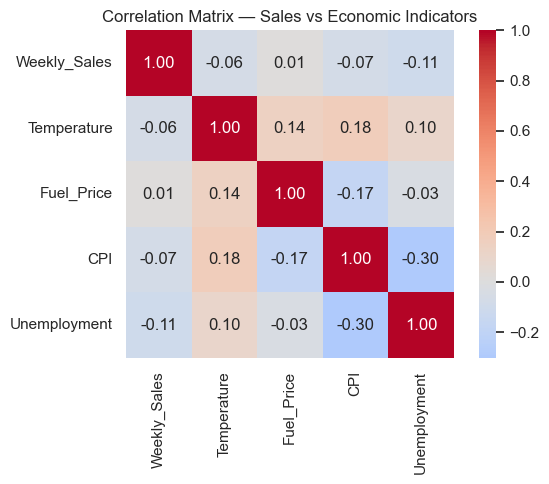

Weekly_Sales    1.00
Fuel_Price      0.01
Temperature    -0.06
CPI            -0.07
Unemployment   -0.11
Name: Weekly_Sales, dtype: float64


In [16]:
corr_cols = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
corr_matrix = df_clean[corr_cols].corr()

plt.figure(figsize=(6.5, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Matrix — Sales vs Economic Indicators')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/07_correlation_heatmap.png', bbox_inches='tight')
plt.show()

print(corr_matrix['Weekly_Sales'].sort_values(ascending=False))


**Finding:** all four correlations are weak (|r| < 0.11). Unemployment has the strongest
relationship (-0.11) and fuel price the weakest (0.01) — none are practically meaningful. This is an
important, slightly counter-intuitive insight worth stating plainly in the dashboard: **at this level
of aggregation, macroeconomic conditions are not meaningful predictors of weekly sales** — store
identity and calendar seasonality explain far more variance than CPI, unemployment,
fuel prices, or temperature do. A junior analyst might assume these economic columns are the headline
story; a senior analyst checks first and reports that they aren't.

## 14. Outlier Detection

Apply the standard IQR rule to flag statistical outliers in `Weekly_Sales`, then investigate *why*
they occur rather than just removing them — outliers in real retail data are often the most
important rows, not noise to discard.

In [17]:
Q1 = df_clean['Weekly_Sales'].quantile(0.25)
Q3 = df_clean['Weekly_Sales'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_clean[(df_clean['Weekly_Sales'] < lower_bound) | (df_clean['Weekly_Sales'] > upper_bound)]
print(f'Outlier rows: {len(outliers)} ({len(outliers)/len(df_clean)*100:.2f}% of data)')
print(f'IQR bounds: [{lower_bound:,.0f}, {upper_bound:,.0f}]')
print()
outliers[['Store','Date','Weekly_Sales','Holiday_Flag','Month_Name']].sort_values('Weekly_Sales', ascending=False).head(10)


Outlier rows: 34 (0.53% of data)
IQR bounds: [-746,863, 2,720,371]



,Store,Date,Weekly_Sales,Holiday_Flag,Month_Name
1905,14,2010-12-24,"3,818,686.45",0,December
2763,20,2010-12-24,"3,766,687.43",0,December
1333,10,2010-12-24,"3,749,057.69",0,December
527,4,2011-12-23,"3,676,388.98",0,December
1762,13,2010-12-24,"3,595,903.20",0,December
1814,13,2011-12-23,"3,556,766.03",0,December
2815,20,2011-12-23,"3,555,371.03",0,December
475,4,2010-12-24,"3,526,713.39",0,December
1385,10,2011-12-23,"3,487,986.89",0,December
189,2,2010-12-24,"3,436,007.68",0,December


In [18]:
print('Calendar dates that ARE flagged Holiday_Flag = 1:')
print(sorted(df_clean.loc[df_clean['Holiday_Flag']==1, 'Date'].dt.strftime('%Y-%m-%d').unique()))
print()
print('Dates of the top 10 highest-sales outlier weeks:')
print(sorted(outliers.sort_values('Weekly_Sales', ascending=False).head(10)['Date'].dt.strftime('%Y-%m-%d').unique()))


Calendar dates that ARE flagged Holiday_Flag = 1:
['2010-02-12', '2010-09-10', '2010-11-26', '2010-12-31', '2011-02-11', '2011-09-09', '2011-11-25', '2011-12-30', '2012-02-10', '2012-09-07']

Dates of the top 10 highest-sales outlier weeks:
['2010-12-24', '2011-12-23']


**Finding — a genuine data quality gotcha worth flagging in the project writeup:** all of the
extreme high-sales outliers fall in the week of **December 23–24**, but `Holiday_Flag` only marks the
week ending **December 31** as the Christmas holiday week. In other words, the dataset's holiday
label captures the calendar week *containing* Christmas Day, but the actual pre-Christmas shopping
spike happens the week *before* that — so `Holiday_Flag` systematically under-credits the Christmas
effect. This is exactly the kind of labeling nuance a senior analyst calls out rather than silently
inheriting: the holiday lift computed, is a *conservative* estimate of the true
Christmas effect on sales, since the single biggest sales week each year isn't even flagged as a
holiday in the source data.

## Export Cleaned & Feature-Engineered Dataset


In [19]:
export_cols = [
    'Store', 'Date', 'Year', 'Month', 'Month_Name', 'Quarter', 'Week_Of_Year',
    'Weekly_Sales', 'Holiday_Flag', 'Is_Holiday_Week', 'Store_Tier',
    'WoW_Sales_Change_Pct', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment'
]

df_export = df_clean[export_cols].copy()
df_export.to_csv('../data/processed/walmart_sales_cleaned.csv', index=False)
print('Exported:', df_export.shape, '->', '../data/processed/walmart_sales_cleaned.csv')
df_export.head()


Exported: (6435, 16) -> ../data/processed/walmart_sales_cleaned.csv


,Store,Date,Year,Month,Month_Name,Quarter,Week_Of_Year,Weekly_Sales,Holiday_Flag,Is_Holiday_Week,Store_Tier,WoW_Sales_Change_Pct,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,2010,2,February,1,5,"1,643,690.90",0,Non-Holiday,A - Top 25%,NaN,42.31,2.57,211.10,8.11
1,1,2010-02-12,2010,2,February,1,6,"1,641,957.44",1,Holiday,A - Top 25%,-0.11,38.51,2.55,211.24,8.11
2,1,2010-02-19,2010,2,February,1,7,"1,611,968.17",0,Non-Holiday,A - Top 25%,-1.83,39.93,2.51,211.29,8.11
3,1,2010-02-26,2010,2,February,1,8,"1,409,727.59",0,Non-Holiday,A - Top 25%,-12.55,46.63,2.56,211.32,8.11
4,1,2010-03-05,2010,3,March,1,9,"1,554,806.68",0,Non-Holiday,A - Top 25%,10.29,46.50,2.62,211.35,8.11
